In [2]:
from math import lgamma

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# How Safe Are Bitcoin Confirmations?
## A Probabilistic Analysis of Double-Spend Risk in Bitcoin Proof of Work

### Abstract
Bitcoin does not offer *absolute* transaction finality. Instead, the security of a confirmed transaction is probabilistic: an attacker who controls a fraction $q$ of the total hash power may still try to reverse a payment by secretly mining a competing chain. The central question of this project is therefore:

> **How quickly does double-spend risk decrease as the number of confirmations grows?**

This notebook studies that question with three complementary methods:

1. an **exact** probabilistic model based on the negative binomial distribution,
2. the **Poisson approximation** used in the original Bitcoin whitepaper,
3. and **Monte Carlo simulation** as an independent computational check.

The analysis is built step by step. We begin with Bernoulli trials, geometric waiting times, exponential block times, and Poisson processes. We then derive the *fixed-deficit* catch-up probability, model the attacker's hidden progress during the confirmation window, compare the exact and approximate formulas, and measure how large the approximation errors are in practice.

### Central thesis
**Bitcoin confirmation security is probabilistic rather than absolute, and the practical safety of waiting for $z$ confirmations depends strongly on both the attacker's hash-power share $q$ and the mathematical method used to estimate the attacker's hidden progress.**


## 1. Introduction

Bitcoin uses **Proof of Work (PoW)** to decide which chain of blocks becomes the accepted history of transactions. Miners repeatedly compute hashes until one of them finds a valid block. Each accepted block extends the blockchain, and each additional block on top of a transaction is called a **confirmation**.

The folk intuition is that "more confirmations means more safety." That intuition is correct, but it is incomplete. The missing detail is that the protection is **probabilistic**, not deterministic. If an attacker pays a merchant and simultaneously begins mining a secret competing chain, then even after the merchant sees $z$ honest confirmations, the attacker may still succeed later by catching up and overtaking the honest chain.


### 1.1 Why this problem matters

The phrase "wait for six confirmations" is common in discussions of Bitcoin transaction security. However, such a rule only makes sense after answering at least three deeper questions:

1. **What stochastic process describes block discovery?**
2. **How should we model the attacker's hidden chain during the waiting period?**
3. **How fast does attack success probability actually decay as confirmations accumulate?**

A good mathematical model should not merely repeat folklore. It should explain *why* the rule works when it works, *when* it becomes weak, and *how* the result changes when the attacker controls more computational power.



### 1.2 Research questions and thesis

This project answers the following research questions.

1. **How can block discovery be modeled mathematically?**
2. **If the attacker is currently $d$ blocks behind, what is the probability of eventually catching up?**
3. **While the merchant waits for $z$ honest confirmations, how many secret blocks is the attacker likely to mine?**
4. **What is the exact double-spend success probability once we combine those two pieces?**
5. **How accurate is Nakamoto's Poisson approximation relative to the exact negative-binomial model?**
6. **How many confirmations are required to push risk below practical thresholds such as $10^{-2}$, $10^{-3}$, or $10^{-6}$?**

The thesis stated at the start of the notebook will be evaluated against the numerical results at the end.



## 2. Mathematical Background

To model Bitcoin confirmations rigorously, we first need a probabilistic description of mining itself. The important idea is that mining is not a deterministic race with a fixed finish time. It is a **random process** driven by a very large number of repeated hash attempts.


Throughout this section, the goal is not to use the most advanced theory possible. The goal is to start from simple probability models and build upward one step at a time.


### 2.1 Hashing as a Bernoulli process

Suppose that a single hash attempt succeeds with probability $s$, where success means "the hash is below the current target." Then each attempt is a **Bernoulli trial**:

$$
\Pr(\text{success}) = s, \qquad \Pr(\text{failure}) = 1-s.
$$

If $N$ is the number of independent attempts until the first success, then $N$ follows a **geometric distribution**:

$$
\Pr(N=n) = (1-s)^{n-1}s, \qquad n=1,2,3,\dots
$$

The geometric distribution is the right discrete model because:

- the trials are repeated independently,
- each trial has the same success probability $s$,
- and the process stops at the first success.

Two basic facts are immediately useful:

$$
\mathbb{E}[N] = \frac{1}{s}, \qquad
\mathrm{Var}(N) = \frac{1-s}{s^2}.
$$

These formulas say that when $s$ is extremely small, the expected number of trials before success is enormous. That is exactly the PoW setting: a block is *rare* relative to the number of attempted hashes.



### 2.2 From geometric waiting times to exponential block times

Mining hardware does not perform one hash every few minutes; it performs an enormous number of hashes per second. If a miner produces $r$ independent attempts per unit time, then after a short interval $\Delta t$ the success probability is approximately

$$
\Pr(\text{success in } \Delta t) \approx r s \, \Delta t.
$$

In the limit of many tiny time slices, the waiting time $T$ to the next block is modeled by an **exponential distribution** with rate $\lambda = rs$:

$$
f_T(t) = \lambda e^{-\lambda t}, \qquad t \ge 0,
$$

$$
\Pr(T > t) = e^{-\lambda t},
\qquad
\mathbb{E}[T] = \frac{1}{\lambda},
\qquad
\mathrm{Var}(T) = \frac{1}{\lambda^2}.
$$

This transition from a geometric count of trials to an exponential waiting time is not a change in underlying logic. It is the continuous-time limit of the same Bernoulli mechanism.

For Bitcoin, the protocol adjusts difficulty so that the *network-wide* expected inter-block time is close to 10 minutes. In our notation, that means

$$
\lambda_{\text{network}} \approx \frac{1}{10} \text{ blocks per minute}.
$$

An important conceptual consequence of the exponential model is the **memoryless property**: a long time without a block does not make a block "overdue." The probability law of the *remaining* waiting time is the same as it was at the beginning.



### 2.3 Simulating network block times

Before building the security model, it is useful to validate the exponential waiting-time intuition numerically. The code below draws many synthetic block intervals from an exponential distribution with mean 10 minutes and overlays the theoretical density

$$
f_T(t) = \lambda e^{-\lambda t}, \qquad \lambda = \frac{1}{10}.
$$

The purpose of this plot is not to "discover" the formula experimentally; the formula comes first. The simulation is a sanity check that helps connect the mathematics to an observable distribution.


In [3]:
# Plot settings
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 11

# Pandas display format
pd.options.display.float_format = "{:,.6f}".format

# Reproducibility
SEED = 42

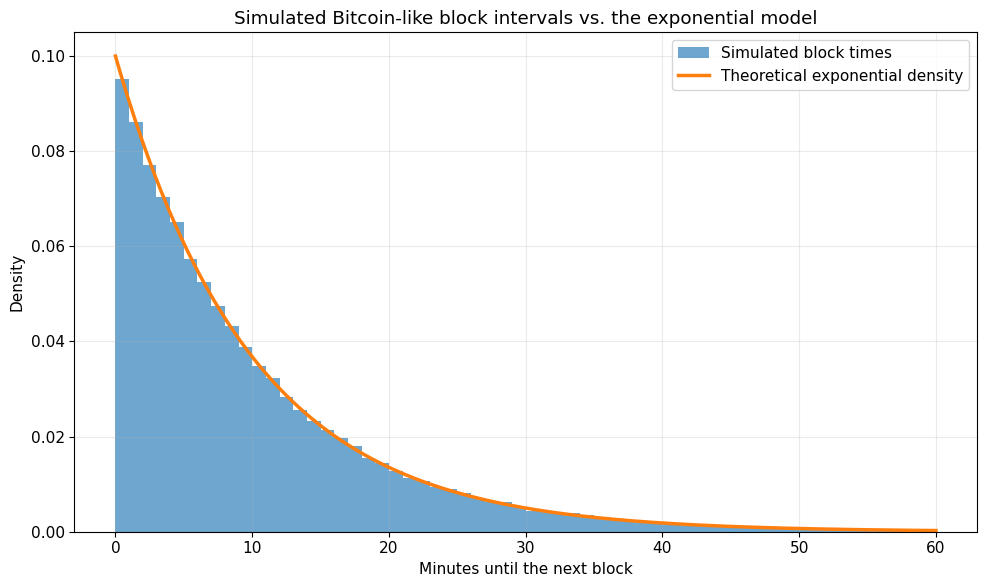

,Statistic,Value
0,Sample mean,10.034967
1,Theoretical mean,10.000000
2,Sample variance,101.061594
3,Theoretical variance,100.000000


In [5]:
def simulate_block_times(n_blocks, mean_minutes=10.0, seed=7):
    rng = np.random.default_rng(seed)
    return rng.exponential(scale=mean_minutes, size=n_blocks)


block_times = simulate_block_times(n_blocks=100_000, mean_minutes=10.0, seed=SEED)
rate = 1 / 10.0

x = np.linspace(0, 60, 500)
pdf = rate * np.exp(-rate * x)

fig, ax = plt.subplots()
ax.hist(block_times, bins=60, density=True, alpha=0.65, range=(0, 60), label="Simulated block times")
ax.plot(x, pdf, linewidth=2.5, label="Theoretical exponential density")
ax.set_title("Simulated Bitcoin-like block intervals vs. the exponential model")
ax.set_xlabel("Minutes until the next block")
ax.set_ylabel("Density")
ax.legend()
fig.tight_layout()
plt.show()

summary_block_times = pd.DataFrame(
    {
        "Statistic": ["Sample mean", "Theoretical mean", "Sample variance", "Theoretical variance"],
        "Value": [
            block_times.mean(),
            10.0,
            block_times.var(ddof=1),
            100.0,
        ],
    }
)
summary_block_times



The histogram follows the theoretical exponential shape quite closely. The main lesson is conceptual:

- **short waiting times are common,**
- **very long waiting times are possible but rare,**
- and **there is no deterministic schedule for the next block.**

That randomness is exactly what makes confirmation security a probabilistic question instead of a simple counting rule.



### 2.4 Competing Poisson processes

Now split the network into two groups:

- honest miners with hash-power share $p$,
- an attacker with hash-power share $q$,

with

$$
p+q=1, \qquad 0 < q < 1.
$$

If the whole network has block-arrival rate $\lambda$, then the two sides can be modeled as independent Poisson processes with rates

$$
\lambda_h = p\lambda, \qquad \lambda_a = q\lambda.
$$

Let $T_h \sim \mathrm{Exp}(\lambda_h)$ be the waiting time to the next honest block and $T_a \sim \mathrm{Exp}(\lambda_a)$ the waiting time to the next attacker block. Then the probability that the *next* block belongs to the attacker is

$$
\Pr(T_a < T_h)
= \frac{\lambda_a}{\lambda_a + \lambda_h}
= \frac{q\lambda}{q\lambda + p\lambda}
= q.
$$

Likewise,

$$
\Pr(T_h < T_a) = p.
$$

This result is crucial. It shows that once we focus on the **sequence of block discoveries**, the continuous-time race reduces to a simple discrete random walk in which each new block is honest with probability $p$ and attacker-generated with probability $q$.



## 3. Building the Double-Spend Model

We now turn the stochastic intuition into a security model for confirmations.



### 3.1 Assumptions and notation

Throughout the notebook, we use the standard Bitcoin double-spend notation:

- $q$: attacker's fraction of total hash power,
- $p = 1-q$: honest fraction of total hash power,
- $z$: number of honest confirmations waited by the recipient,
- $d$: current block deficit of the attacker relative to the honest chain.

The mathematical model makes the following simplifying assumptions.

1. **Constant hash-power shares.** The values of $p$ and $q$ do not change during the attack.
2. **Independent block races.** Each new block is found by the honest network with probability $p$ and by the attacker with probability $q$.
3. **No network delays or propagation asymmetries.** The model isolates the probabilistic core and ignores networking effects.
4. **The attacker always continues optimally.** If the attacker still has a positive chance of catching up, the model counts eventual success accordingly.
5. **The security question is purely probabilistic.** We are not modeling economics, fees, or strategic incentives.

These assumptions are idealized, but they make the core mathematics transparent and are standard in the literature on hash-rate-based double spending.



### 3.2 Catch-up probability from a fixed deficit

First consider a simpler question. Suppose the attacker is already $d$ blocks behind. What is the probability of *eventually* catching up?

Let $a_d$ denote that probability. The next discovered block changes the deficit by exactly one unit:

- with probability $q$, the attacker finds the next block, so the deficit becomes $d-1$;
- with probability $p$, the honest network finds the next block, so the deficit becomes $d+1$.

Therefore the probabilities satisfy the recurrence

$$
a_d = q\,a_{d-1} + p\,a_{d+1},
\qquad d \ge 1,
$$

with boundary condition

$$
a_0 = 1,
$$

because if the attacker has already caught up, the event has occurred.

For $q < p$, the bounded solution of this recurrence is

$$
a_d = \left(\frac{q}{p}\right)^d.
$$

This formula is one of the most important results in the notebook. In plain language, when the attacker has strictly less than half of the hash power, **every extra block of deficit multiplies the chance of recovery by the factor $q/p$**. That is what geometric decay means in this setting.

If $q \ge p$, the attacker is not at a probabilistic disadvantage, and the eventual catch-up probability becomes

$$
a_d = 1.
$$

So the key message is simple: **below 50% hash power, more confirmations help very quickly; at or above 50%, confirmations no longer create the same kind of probabilistic safety in this infinite-horizon model.**


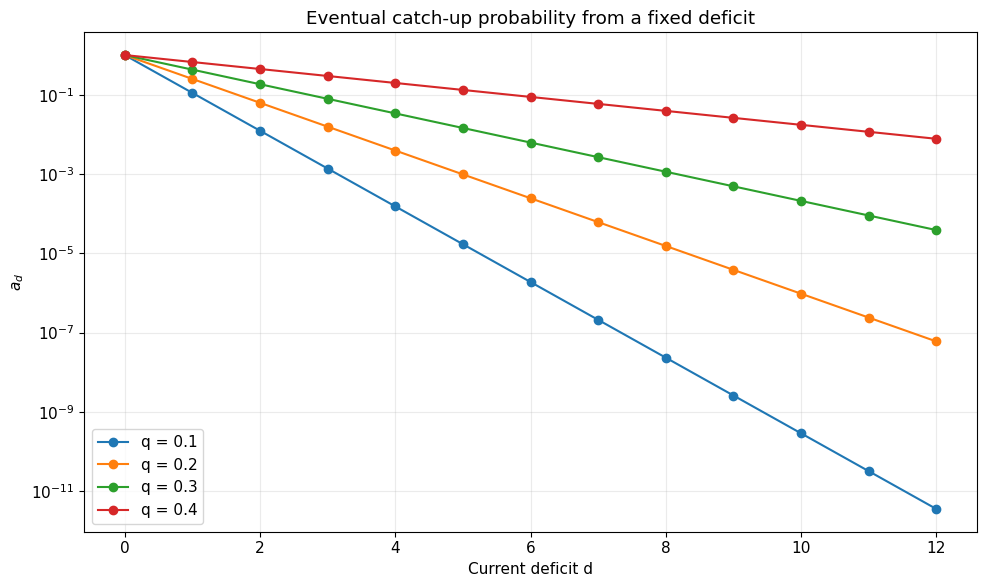

,q=0.1,q=0.2,q=0.3,q=0.4
Deficit d,,,,
0,1.000000,1.000000,1.000000,1.000000
1,0.111111,0.250000,0.428571,0.666667
2,0.012346,0.062500,0.183673,0.444444
3,0.001372,0.015625,0.078717,0.296296
4,0.000152,0.003906,0.033736,0.197531
5,0.000017,0.000977,0.014458,0.131687
6,0.000002,0.000244,0.006196,0.087791
7,0.000000,0.000061,0.002656,0.058528


In [7]:
def catch_up_probability_from_deficit(deficit, attacker_share):
    honest_share = 1.0 - attacker_share
    deficit = np.asarray(deficit, dtype=int)

    if attacker_share >= honest_share:
        return np.ones_like(deficit, dtype=float)

    ratio = attacker_share / honest_share
    return np.where(deficit <= 0, 1.0, ratio ** deficit).astype(float)


deficits = np.arange(0, 13)
attacker_shares = [0.1, 0.2, 0.3, 0.4]

catch_up_table = pd.DataFrame(
    {
        f"q={q:.1f}": catch_up_probability_from_deficit(deficits, q)
        for q in attacker_shares
    },
    index=deficits,
)
catch_up_table.index.name = "Deficit d"

fig, ax = plt.subplots()
for q in attacker_shares:
    ax.plot(deficits, catch_up_probability_from_deficit(deficits, q), marker="o", label=f"q = {q:.1f}")
ax.set_title("Eventual catch-up probability from a fixed deficit")
ax.set_xlabel("Current deficit d")
ax.set_ylabel(r"$a_d$")
ax.set_yscale("log")
ax.legend()
fig.tight_layout()
plt.show()

catch_up_table.head(8)



The log-scale plot highlights the geometric structure very clearly. For each fixed attacker share $q<0.5$, the graph becomes an approximately straight line because

$$
\log a_d = d \log\!\left(\frac{q}{p}\right).
$$

That is exactly what exponential decay looks like after applying a logarithm. The slope becomes less negative as $q$ approaches $0.5$, which means the decay becomes slower and security improves less quickly.



### 3.3 Attacker progress during the confirmation window

The fixed-deficit formula is not yet the final answer, because a merchant does not usually ask: "What if the attacker starts $d$ blocks behind right now?" Instead, the merchant waits for $z$ confirmations while the attacker is already mining a private branch.

Let $K$ be the number of attacker blocks found **before** the honest network accumulates $z$ blocks. Then the attacker is not necessarily $z$ blocks behind when the merchant accepts the payment. The actual remaining deficit is

$$
d = z - K.
$$

This random variable $K$ follows a **negative binomial distribution**:

$$
\Pr(K = k) = \binom{k+z-1}{k} p^z q^k,
\qquad k = 0,1,2,\dots
$$

Why is that the correct formula?

- We stop exactly when the $z$-th honest block appears.
- Before that final honest block, the attacker may have produced $k$ secret blocks.
- In the first $k+z-1$ block discoveries, we must see exactly $k$ attacker blocks and $z-1$ honest blocks.
- The last discovery is forced to be honest.

That is precisely the counting logic behind the negative binomial model.

Its first two moments are especially informative:

$$
\mathbb{E}[K] = \frac{zq}{p},
\qquad
\mathrm{Var}(K) = \frac{zq}{p^2}.
$$

The expectation tells us the average attacker progress during the waiting window. The variance tells us that the hidden progress can fluctuate substantially, especially when $q$ is not tiny.


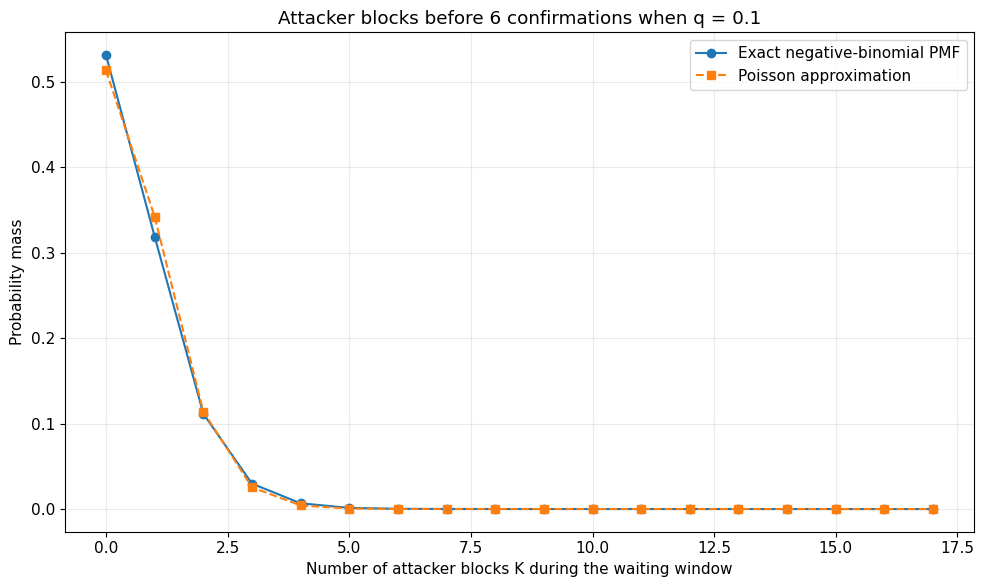

,Expected attacker blocks E[K],Variance Var(K),Standard deviation
"q = 0.1, z = 6",0.666667,0.740741,0.860663
"q = 0.3, z = 6",2.571429,3.673469,1.916630


In [14]:
def negative_binomial_attacker_pmf(k_values, confirmations, attacker_share):
    honest_share = 1.0 - attacker_share
    k_values = np.asarray(k_values, dtype=int)

    log_coeff = (
        np.vectorize(lgamma)(k_values + confirmations)
        - np.vectorize(lgamma)(k_values + 1)
        - lgamma(confirmations)
    )
    log_pmf = (
        log_coeff
        + confirmations * np.log(honest_share)
        + k_values * np.log(attacker_share)
    )
    return np.exp(log_pmf)


def poisson_attacker_pmf(k_values, confirmations, attacker_share):
    honest_share = 1.0 - attacker_share
    lam = confirmations * attacker_share / honest_share
    k_values = np.asarray(k_values, dtype=int)

    log_pmf = -lam + k_values * np.log(lam) - np.vectorize(lgamma)(k_values + 1)
    log_pmf = np.where(k_values == 0, -lam, log_pmf)
    return np.exp(log_pmf)


def expected_attacker_blocks(confirmations, attacker_share):
    honest_share = 1.0 - attacker_share
    return confirmations * attacker_share / honest_share


def variance_attacker_blocks(confirmations, attacker_share):
    honest_share = 1.0 - attacker_share
    return confirmations * attacker_share / (honest_share ** 2)


q_small = 0.1
z_wait = 6
k_values = np.arange(0, 18)

pmf_exact_small = negative_binomial_attacker_pmf(
    k_values,
    confirmations=z_wait,
    attacker_share=q_small
)
pmf_poisson_small = poisson_attacker_pmf(
    k_values,
    confirmations=z_wait,
    attacker_share=q_small
)

fig, ax = plt.subplots()
ax.plot(k_values, pmf_exact_small, marker="o", label="Exact negative-binomial PMF")
ax.plot(k_values, pmf_poisson_small, marker="s", linestyle="--", label="Poisson approximation")
ax.set_title("Attacker blocks before 6 confirmations when q = 0.1")
ax.set_xlabel("Number of attacker blocks K during the waiting window")
ax.set_ylabel("Probability mass")
ax.legend()
fig.tight_layout()
plt.show()

moment_table = pd.DataFrame(
    {
        "Expected attacker blocks E[K]": [
            expected_attacker_blocks(6, 0.1),
            expected_attacker_blocks(6, 0.3),
        ],
        "Variance Var(K)": [
            variance_attacker_blocks(6, 0.1),
            variance_attacker_blocks(6, 0.3),
        ],
        "Standard deviation": [
            np.sqrt(variance_attacker_blocks(6, 0.1)),
            np.sqrt(variance_attacker_blocks(6, 0.3)),
        ],
    },
    index=["q = 0.1, z = 6", "q = 0.3, z = 6"],
)

moment_table

For $q=0.1$ and $z=6$, the distribution is concentrated near very small attacker progress, which matches intuition: a weak attacker usually finds few blocks while the honest chain advances by six. Even in this mild case, however, the mass is not concentrated at $K=0$. The attacker often finds one or two secret blocks before the merchant accepts the payment, and those blocks matter because the fixed-deficit catch-up probability is exponentially sensitive to the remaining deficit.


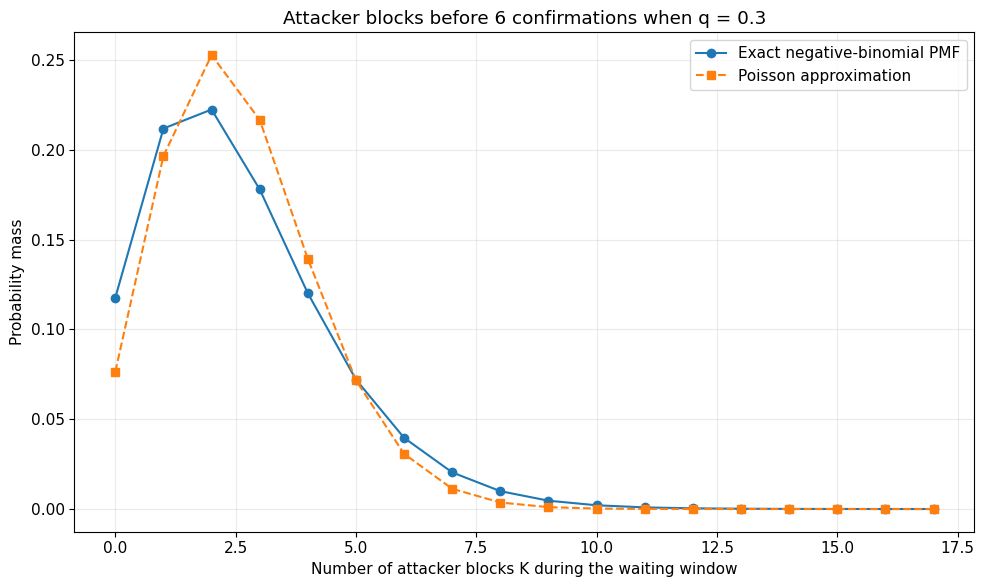

,K,Exact PMF (q = 0.3),Poisson PMF (q = 0.3),Absolute difference
0,0,0.117649,0.076426,0.041223
1,1,0.211768,0.196525,0.015243
2,2,0.222357,0.252675,0.030318
3,3,0.177885,0.216578,0.038693
4,4,0.120073,0.139229,0.019156
5,5,0.072044,0.071603,0.000440
6,6,0.039624,0.030687,0.008937
7,7,0.020378,0.011273,0.009105
8,8,0.009934,0.003623,0.006311
9,9,0.004636,0.001035,0.003601


In [15]:
q_large = 0.3
z_wait = 6
k_values = np.arange(0, 18)

pmf_exact_large = negative_binomial_attacker_pmf(
    k_values,
    confirmations=z_wait,
    attacker_share=q_large
)
pmf_poisson_large = poisson_attacker_pmf(
    k_values,
    confirmations=z_wait,
    attacker_share=q_large
)

fig, ax = plt.subplots()
ax.plot(k_values, pmf_exact_large, marker="o", label="Exact negative-binomial PMF")
ax.plot(k_values, pmf_poisson_large, marker="s", linestyle="--", label="Poisson approximation")
ax.set_title("Attacker blocks before 6 confirmations when q = 0.3")
ax.set_xlabel("Number of attacker blocks K during the waiting window")
ax.set_ylabel("Probability mass")
ax.legend()
fig.tight_layout()
plt.show()

pmf_comparison_table = pd.DataFrame(
    {
        "K": k_values,
        "Exact PMF (q = 0.3)": pmf_exact_large,
        "Poisson PMF (q = 0.3)": pmf_poisson_large,
        "Absolute difference": np.abs(pmf_exact_large - pmf_poisson_large),
    }
)

pmf_comparison_table.head(10)

When $q=0.3$, the distribution shifts visibly to the right. The attacker now accumulates meaningful hidden progress during the confirmation window, and the Poisson approximation becomes less obviously faithful to the exact negative-binomial law. This is an early hint that the final attack probabilities may also deviate.



### 3.4 Exact double-spend success probability

We now combine the two previous pieces.

Before writing the formula, here is the idea in one sentence:

> **We look at every possible amount of hidden attacker progress, compute the success chance in that case, and then average those chances using the probabilities of the cases.**

In symbols:

- the attacker mines $K$ secret blocks while the honest network reaches $z$ confirmations,
- after that point, the remaining deficit is $z-K$,
- and conditional on that deficit, the eventual catch-up probability is $a_{z-K}$.

Therefore the **exact** attack success probability is the weighted average

$$
P_{\text{exact}}(z,q)
= \sum_{k=0}^{\infty} \Pr(K=k)\,a_{z-k}.
$$

Substituting the formulas derived above gives

$$
P_{\text{exact}}(z,q)
=
\sum_{k=0}^{\infty}
\binom{k+z-1}{k} p^z q^k
\cdot
\begin{cases}
1, & k \ge z, \\
\left(\frac{q}{p}\right)^{z-k}, & k < z,
\end{cases}
\qquad p = 1-q.
$$

This formula is exact under our assumptions. It is the central object of the project.


This is a good place to slow down when reading. The formula is not conceptually difficult; it is just a careful bookkeeping rule that adds together many possible scenarios.


### 3.5 Nakamoto's Poisson approximation

In the Bitcoin whitepaper, the hidden attacker progress is approximated by a Poisson random variable with parameter

$$
\lambda = \frac{zq}{p}.
$$

Under that approximation,

$$
K \approx \mathrm{Poisson}(\lambda),
\qquad
\Pr(K=k) \approx e^{-\lambda}\frac{\lambda^k}{k!}.
$$

That yields the approximate success probability

$$
P_{\text{Poisson}}(z,q)
=
\sum_{k=0}^{\infty}
e^{-\lambda}\frac{\lambda^k}{k!}
\cdot
\begin{cases}
1, & k \ge z, \\
\left(\frac{q}{p}\right)^{z-k}, & k < z.
\end{cases}
$$

The Poisson model is elegant and historically important, but it is still an approximation. One of the main goals of the notebook is to measure how far it deviates from the exact negative-binomial calculation.


## 4. Comparison Strategy and Evaluation Metrics

Before moving to the experiments, it is useful to say clearly **what is being compared** and **how the comparison will be judged**.

### 4.1 The three methods in this notebook

We will compare three ways to study the same double-spend question.

1. **Exact model.**  
   This is the main benchmark of the project. It uses the negative binomial distribution for the attacker's hidden progress and then averages the fixed-deficit catch-up probabilities.

2. **Poisson approximation.**  
   This is the simplified method used in Nakamoto's whitepaper. It is easier to compute and easier to write down, but it may introduce approximation error.

3. **Monte Carlo simulation.**  
   This method repeatedly samples random mining outcomes and estimates the success probability by empirical frequency. It is useful as an implementation check because it does not reuse the exact formula directly.

### 4.2 Metrics used in the evaluation

To compare the exact and approximate methods, we will measure both **absolute** and **relative** error.

The absolute error is

$$
E_{\text{abs}}(z,q)
=
\left|P_{\text{Poisson}}(z,q) - P_{\text{exact}}(z,q)\right|.
$$

The relative error is

$$
E_{\text{rel}}(z,q)
=
\frac{\left|P_{\text{Poisson}}(z,q) - P_{\text{exact}}(z,q)\right|}{P_{\text{exact}}(z,q)}.
$$

The absolute error tells us the difference in probability units.  
The relative error tells us the difference as a fraction of the exact value.

Both are useful. When the true probability is extremely small, a tiny absolute error can still look large in relative terms, so it is safer to report both metrics.

For the Monte Carlo validation, we will use the simulation difference

$$
E_{\text{MC}}(z,q)
=
\left|\widehat{P}_{\text{MC}}(z,q) - P_{\text{exact}}(z,q)\right|.
$$

Here $\widehat{P}_{\text{MC}}(z,q)$ is the simulated estimate obtained from many repeated trials.


## 5. Experiments and Results

The rest of the notebook answers the research questions numerically.



### 5.1 Exact attack probability versus the number of confirmations

We begin with the main quantity of interest:

$$
P_{\text{exact}}(z,q).
$$

The next plot shows how this probability changes as the confirmation count $z$ grows for several attacker hash-power shares.


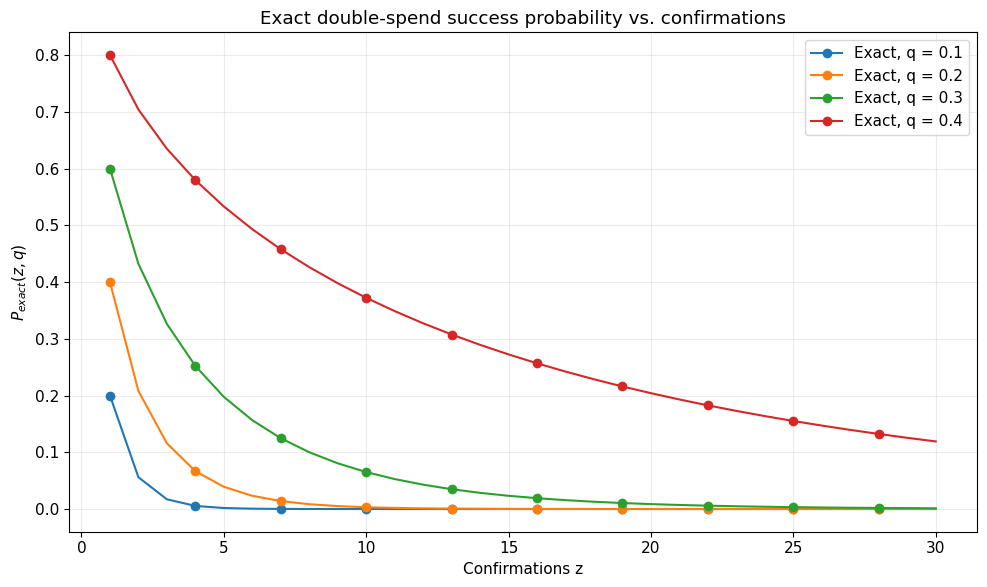

,q=0.1,q=0.2,q=0.3,q=0.4
Confirmations z,,,,
1,0.200000,0.400000,0.600000,0.800000
2,0.056000,0.208000,0.432000,0.704000
3,0.017120,0.115840,0.326160,0.634880
6,0.000591,0.023308,0.156450,0.493004
10,0.000008,0.003158,0.065107,0.372184
20,0.000000,0.000027,0.008674,0.204117


In [7]:
def catch_up_probability_from_deficit(deficit, attacker_share):
    honest_share = 1.0 - attacker_share
    deficit = np.asarray(deficit, dtype=int)

    if attacker_share >= honest_share:
        return np.ones_like(deficit, dtype=float)

    ratio = attacker_share / honest_share
    return np.where(deficit <= 0, 1.0, ratio ** deficit).astype(float)


def exact_attack_success_probability(confirmations, attacker_share, tail_probability=1e-14):
    honest_share = 1.0 - attacker_share

    if attacker_share >= honest_share:
        return 1.0

    total_probability = 0.0
    k = 0
    pmf = honest_share ** confirmations

    while True:
        deficit = confirmations - k
        total_probability += pmf * float(
            catch_up_probability_from_deficit(deficit, attacker_share)
        )

        k += 1
        pmf *= (k + confirmations - 1) / k * attacker_share

        if pmf < tail_probability and k > confirmations + 20:
            break

    return total_probability


def poisson_approx_attack_success_probability(confirmations, attacker_share, tail_probability=1e-14):
    honest_share = 1.0 - attacker_share

    if attacker_share >= honest_share:
        return 1.0

    lam = confirmations * attacker_share / honest_share
    total_probability = 0.0
    k = 0
    pmf = np.exp(-lam)

    while True:
        deficit = confirmations - k
        total_probability += pmf * float(
            catch_up_probability_from_deficit(deficit, attacker_share)
        )

        k += 1
        pmf *= lam / k

        if pmf < tail_probability and k > confirmations + 20:
            break

    return total_probability


def exact_attack_probability_series(confirmations, attacker_share):
    confirmations = list(confirmations)
    return np.array(
        [exact_attack_success_probability(z, attacker_share) for z in confirmations],
        dtype=float
    )


def poisson_attack_probability_series(confirmations, attacker_share):
    confirmations = list(confirmations)
    return np.array(
        [poisson_approx_attack_success_probability(z, attacker_share) for z in confirmations],
        dtype=float
    )


z_values = np.arange(1, 31)
attacker_shares_main = [0.1, 0.2, 0.3, 0.4]

exact_curves = {q: exact_attack_probability_series(z_values, q) for q in attacker_shares_main}
poisson_curves = {q: poisson_attack_probability_series(z_values, q) for q in attacker_shares_main}

fig, ax = plt.subplots()
for q in attacker_shares_main:
    ax.plot(z_values, exact_curves[q], marker="o", markevery=3, label=f"Exact, q = {q:.1f}")
ax.set_title("Exact double-spend success probability vs. confirmations")
ax.set_xlabel("Confirmations z")
ax.set_ylabel(r"$P_{exact}(z, q)$")
ax.legend()
fig.tight_layout()
plt.show()

selected_points = pd.DataFrame(
    {
        f"q={q:.1f}": [exact_attack_success_probability(z, q) for z in [1, 2, 3, 6, 10, 20]]
        for q in attacker_shares_main
    },
    index=[1, 2, 3, 6, 10, 20],
)
selected_points.index.name = "Confirmations z"
selected_points



The curves are decreasing, as expected, but the **speed** of the decrease depends dramatically on $q$.

- For $q=0.1$, the risk becomes very small after a moderate number of confirmations.
- For $q=0.2$, the decay is still meaningful, but noticeably slower.
- For $q=0.3$, the attack remains alarmingly plausible for quite a long time.
- For $q=0.4$, the curve decreases only slowly. Even many confirmations do not produce comfort.

This already supports the thesis that a fixed rule such as "six confirmations is enough" cannot be interpreted without knowing the attacker's relative hash power.


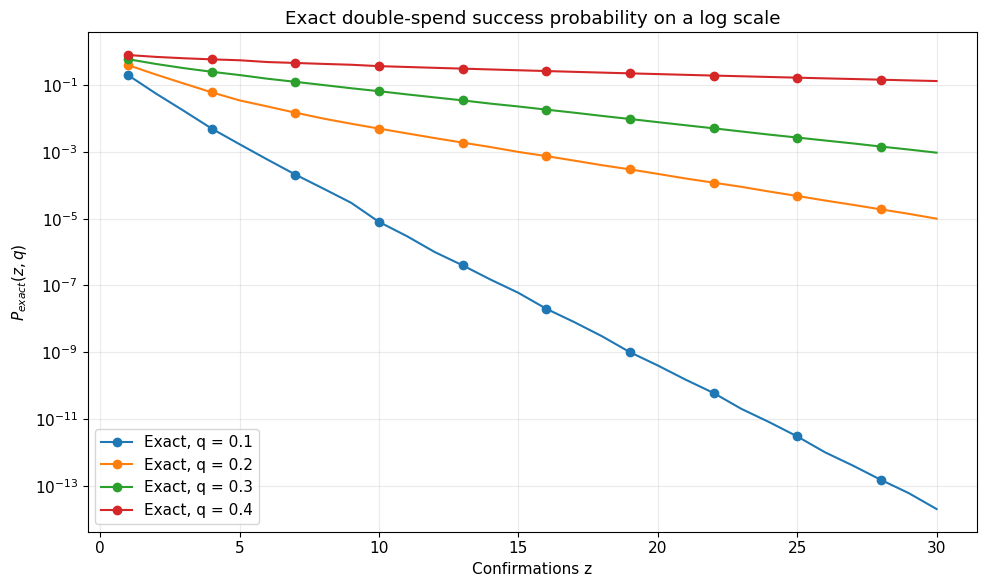

In [11]:
z_values = np.arange(1, 31)
attacker_shares_main = [0.1, 0.2, 0.3, 0.4]

fig, ax = plt.subplots()
for q in attacker_shares_main:
    ax.plot(z_values, exact_curves[q], marker="o", markevery=3, label=f"Exact, q = {q:.1f}")
ax.set_title("Exact double-spend success probability on a log scale")
ax.set_xlabel("Confirmations z")
ax.set_ylabel(r"$P_{exact}(z, q)$")
ax.set_yscale("log")
ax.legend()
fig.tight_layout()
plt.show()



The log-scale version is especially useful because multiplicative decay becomes visually legible. For weaker attackers, the lines descend almost linearly on the log scale, which is exactly what exponential-type decay should look like. As $q$ approaches $0.5$, the slope flattens and each additional confirmation buys much less security.



### 5.2 Exact probabilities versus Nakamoto's Poisson approximation

The next experiment compares the exact negative-binomial model to the Poisson approximation used in the whitepaper. This is not a cosmetic detail. If the approximation is materially biased, then quantitative recommendations based on it may be misleading.


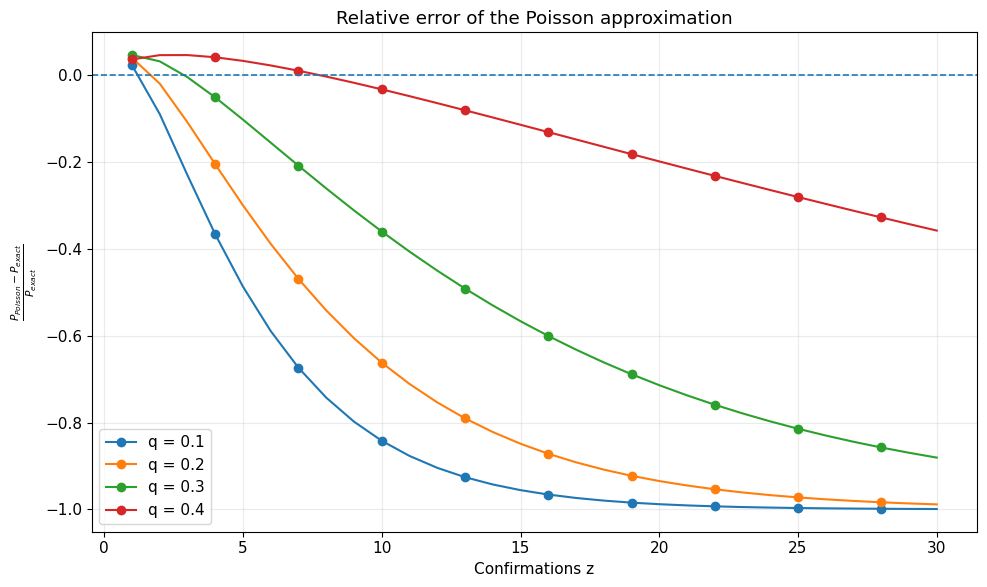

,q,z,Exact,Poisson,Absolute error,Relative error
0,0.100000,3,0.017120,0.013172,-0.003948,-0.230593
1,0.100000,6,0.000591,0.000243,-0.000349,-0.589453
2,0.100000,10,0.000008,0.000001,-0.000007,-0.842056
3,0.100000,20,0.000000,0.000000,-0.000000,-0.988089
4,0.200000,3,0.115840,0.103242,-0.012598,-0.108757
5,0.200000,6,0.023308,0.014251,-0.009058,-0.388607
6,0.200000,10,0.003158,0.001067,-0.002091,-0.662169
7,0.200000,20,0.000027,0.000002,-0.000025,-0.934752
8,0.300000,3,0.326160,0.324584,-0.001576,-0.004832
9,0.300000,6,0.156450,0.132111,-0.024338,-0.155567


In [13]:
def catch_up_probability_from_deficit(deficit, attacker_share):
    honest_share = 1.0 - attacker_share
    deficit = np.asarray(deficit, dtype=int)

    if attacker_share >= honest_share:
        return np.ones_like(deficit, dtype=float)

    ratio = attacker_share / honest_share
    return np.where(deficit <= 0, 1.0, ratio ** deficit).astype(float)


def exact_attack_success_probability(confirmations, attacker_share, tail_probability=1e-14):
    honest_share = 1.0 - attacker_share

    if attacker_share >= honest_share:
        return 1.0

    total_probability = 0.0
    k = 0
    pmf = honest_share ** confirmations

    while True:
        deficit = confirmations - k
        total_probability += pmf * float(
            catch_up_probability_from_deficit(deficit, attacker_share)
        )

        k += 1
        pmf *= (k + confirmations - 1) / k * attacker_share

        if pmf < tail_probability and k > confirmations + 20:
            break

    return total_probability


def poisson_approx_attack_success_probability(confirmations, attacker_share, tail_probability=1e-14):
    honest_share = 1.0 - attacker_share

    if attacker_share >= honest_share:
        return 1.0

    lam = confirmations * attacker_share / honest_share
    total_probability = 0.0
    k = 0
    pmf = np.exp(-lam)

    while True:
        deficit = confirmations - k
        total_probability += pmf * float(
            catch_up_probability_from_deficit(deficit, attacker_share)
        )

        k += 1
        pmf *= lam / k

        if pmf < tail_probability and k > confirmations + 20:
            break

    return total_probability


def exact_attack_probability_series(confirmations, attacker_share):
    confirmations = list(confirmations)
    return np.array(
        [exact_attack_success_probability(z, attacker_share) for z in confirmations],
        dtype=float
    )


def poisson_attack_probability_series(confirmations, attacker_share):
    confirmations = list(confirmations)
    return np.array(
        [poisson_approx_attack_success_probability(z, attacker_share) for z in confirmations],
        dtype=float
    )


z_values = np.arange(1, 31)
attacker_shares_main = [0.1, 0.2, 0.3, 0.4]

exact_curves = {q: exact_attack_probability_series(z_values, q) for q in attacker_shares_main}
poisson_curves = {q: poisson_attack_probability_series(z_values, q) for q in attacker_shares_main}

fig, ax = plt.subplots()
for q in attacker_shares_main:
    relative_error = (poisson_curves[q] - exact_curves[q]) / exact_curves[q]
    ax.plot(z_values, relative_error, marker="o", markevery=3, label=f"q = {q:.1f}")
ax.axhline(0.0, linestyle="--", linewidth=1.2)
ax.set_title("Relative error of the Poisson approximation")
ax.set_xlabel("Confirmations z")
ax.set_ylabel(r"$\frac{P_{Poisson} - P_{exact}}{P_{exact}}$")
ax.legend()
fig.tight_layout()
plt.show()

comparison_rows = []
for q in attacker_shares_main:
    for z in [3, 6, 10, 20]:
        exact_value = exact_attack_success_probability(z, q)
        poisson_value = poisson_approx_attack_success_probability(z, q)
        comparison_rows.append(
            {
                "q": q,
                "z": z,
                "Exact": exact_value,
                "Poisson": poisson_value,
                "Absolute error": poisson_value - exact_value,
                "Relative error": (poisson_value - exact_value) / exact_value,
            }
        )
comparison_table = pd.DataFrame(comparison_rows)
comparison_table


### 5.2.1 A more systematic error summary

The previous plot shows the *shape* of the approximation error. The next table and plot summarize its *size* more directly.

This matters because the Poisson approximation can look visually close to the exact curve while still creating a noticeable error in the final probability estimate.

In [7]:
def catch_up_probability_from_deficit(deficit, attacker_share):
    honest_share = 1.0 - attacker_share
    deficit = np.asarray(deficit, dtype=int)

    if attacker_share >= honest_share:
        return np.ones_like(deficit, dtype=float)

    ratio = attacker_share / honest_share
    return np.where(deficit <= 0, 1.0, ratio ** deficit).astype(float)


def exact_attack_success_probability(confirmations, attacker_share, tail_probability=1e-14):
    honest_share = 1.0 - attacker_share

    if attacker_share >= honest_share:
        return 1.0

    total_probability = 0.0
    k = 0
    pmf = honest_share ** confirmations

    while True:
        deficit = confirmations - k
        total_probability += pmf * float(
            catch_up_probability_from_deficit(deficit, attacker_share)
        )

        k += 1
        pmf *= (k + confirmations - 1) / k * attacker_share

        if pmf < tail_probability and k > confirmations + 20:
            break

    return total_probability


def poisson_approx_attack_success_probability(confirmations, attacker_share, tail_probability=1e-14):
    honest_share = 1.0 - attacker_share

    if attacker_share >= honest_share:
        return 1.0

    lam = confirmations * attacker_share / honest_share
    total_probability = 0.0
    k = 0
    pmf = np.exp(-lam)

    while True:
        deficit = confirmations - k
        total_probability += pmf * float(
            catch_up_probability_from_deficit(deficit, attacker_share)
        )

        k += 1
        pmf *= lam / k

        if pmf < tail_probability and k > confirmations + 20:
            break

    return total_probability


def exact_attack_probability_series(confirmations, attacker_share):
    confirmations = list(confirmations)
    return np.array(
        [exact_attack_success_probability(z, attacker_share) for z in confirmations],
        dtype=float
    )


def poisson_attack_probability_series(confirmations, attacker_share):
    confirmations = list(confirmations)
    return np.array(
        [poisson_approx_attack_success_probability(z, attacker_share) for z in confirmations],
        dtype=float
    )


z_values = np.arange(1, 31)
attacker_shares_main = [0.1, 0.2, 0.3, 0.4]

exact_curves = {
    q: exact_attack_probability_series(z_values, q)
    for q in attacker_shares_main
}

poisson_curves = {
    q: poisson_attack_probability_series(z_values, q)
    for q in attacker_shares_main
}

approximation_summary_rows = []
for q in attacker_shares_main:
    absolute_error = np.abs(poisson_curves[q] - exact_curves[q])
    relative_error = absolute_error / exact_curves[q]
    approximation_summary_rows.append(
        {
            "q": q,
            "Mean absolute error": absolute_error.mean(),
            "Max absolute error": absolute_error.max(),
            "Mean relative error": relative_error.mean(),
            "Max relative error": relative_error.max(),
        }
    )

approximation_summary = pd.DataFrame(approximation_summary_rows)
approximation_summary

,q,Mean absolute error,Max absolute error,Mean relative error,Max relative error
0,0.100000,0.000566,0.005022,0.810152,0.999193
1,0.200000,0.002912,0.015899,0.717056,0.988518
2,0.300000,0.011948,0.027749,0.514832,0.880776
3,0.400000,0.030250,0.043618,0.146593,0.358007


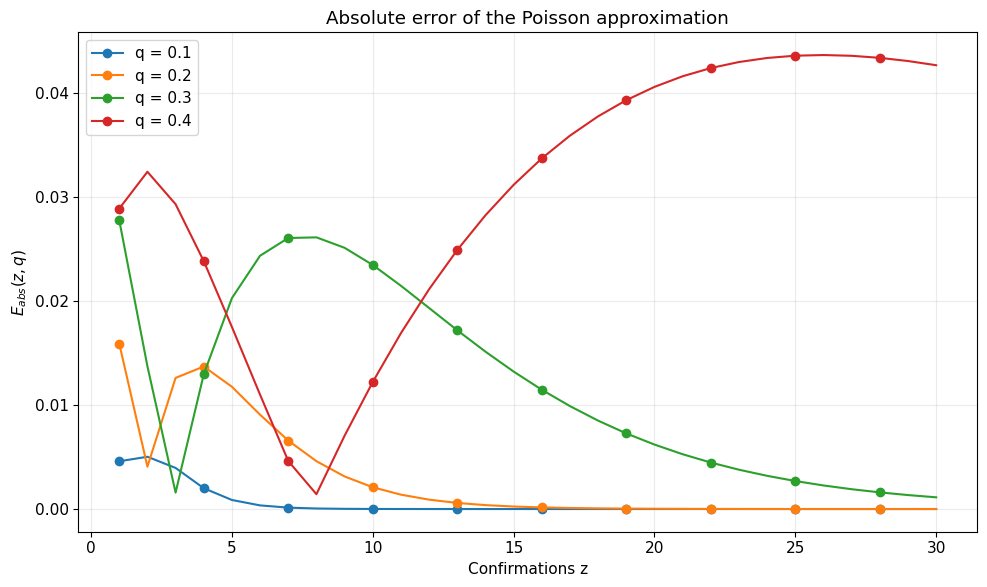

In [8]:
fig, ax = plt.subplots()
for q in attacker_shares_main:
    absolute_error = np.abs(poisson_curves[q] - exact_curves[q])
    ax.plot(z_values, absolute_error, marker="o", markevery=3, label=f"q = {q:.1f}")
ax.set_title("Absolute error of the Poisson approximation")
ax.set_xlabel("Confirmations z")
ax.set_ylabel(r"$E_{abs}(z,q)$")
ax.legend()
fig.tight_layout()
plt.show()

The table and plot together show two useful facts.

- The **absolute** error tends to become larger for stronger attackers.
- The **relative** error can become large even when the probabilities themselves are already tiny.

For that reason, this notebook treats the exact model as the main benchmark and uses the Poisson formula mainly as a compact approximation, not as the final word.


Several patterns emerge.

1. The Poisson approximation is **not uniformly biased in one direction**.
2. For smaller $q$ and moderate $z$, it often **underestimates** the true risk.
3. As $q$ becomes larger, the bias can change sign or shrink at some confirmation levels.
4. The largest practical concern is that an apparently modest approximation error on a plot may correspond to a meaningful difference in recommended confirmations.

For example, when $q=0.1$ and $z=6$, the exact success probability is noticeably larger than the Poisson approximation. That means the approximation is slightly optimistic in a regime where users might wrongly think the attack is already negligible.


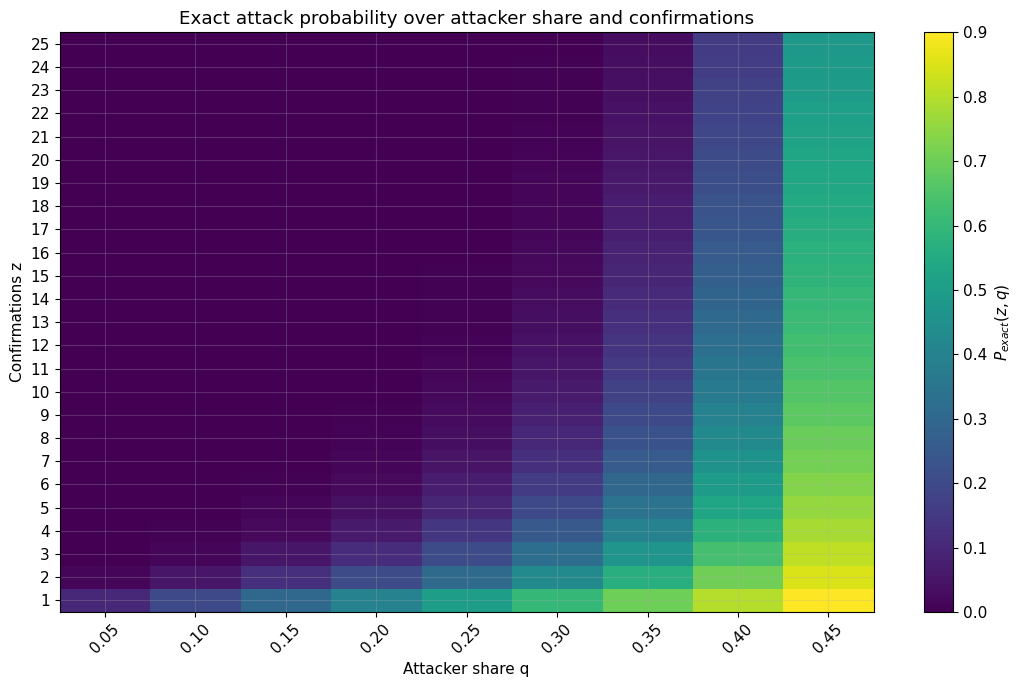

In [10]:
def probability_grid(attacker_shares, confirmations, method="exact"):
    calculations = {
        "exact": exact_attack_success_probability,
        "poisson": poisson_approx_attack_success_probability,
    }

    calculator = calculations[method]
    data = {
        attacker_share: [calculator(z, attacker_share) for z in confirmations]
        for attacker_share in attacker_shares
    }

    frame = pd.DataFrame(data, index=confirmations)
    frame.index.name = "confirmations"
    frame.columns.name = "attacker_share"
    return frame


q_grid = np.round(np.arange(0.05, 0.50, 0.05), 2)
z_grid = np.arange(1, 26)
grid = probability_grid(q_grid, z_grid, method="exact")

fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(grid.values, aspect="auto", origin="lower")
ax.set_title("Exact attack probability over attacker share and confirmations")
ax.set_xlabel("Attacker share q")
ax.set_ylabel("Confirmations z")
ax.set_xticks(np.arange(len(q_grid)))
ax.set_xticklabels([f"{q:.2f}" for q in q_grid], rotation=45)
ax.set_yticks(np.arange(len(z_grid)))
ax.set_yticklabels(z_grid)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$P_{exact}(z, q)$")
fig.tight_layout()
plt.show()



The heatmap makes the geometry of the problem hard to miss. Moving **downward** (more confirmations) reduces risk, but moving **rightward** (larger attacker share) increases risk much faster. The right side of the heatmap remains bright even at high confirmation counts, which visually confirms that strong attackers remain dangerous for a long time.



### 5.3 Monte Carlo validation

A mathematical derivation is stronger when it is independently validated. The next experiment uses Monte Carlo simulation to estimate attack success probabilities and compares those estimates to the exact formula.

The simulation works as follows.

1. Sample the attacker's hidden progress $K$ during the waiting period.
2. Compute the remaining deficit $z-K$.
3. Sample whether the attacker eventually catches up using the fixed-deficit probability $a_{z-K}$.
4. Repeat many times and average the outcomes.

This procedure is probabilistically equivalent to the model definition, so agreement with the exact curve is an implementation check rather than a discovery mechanism.


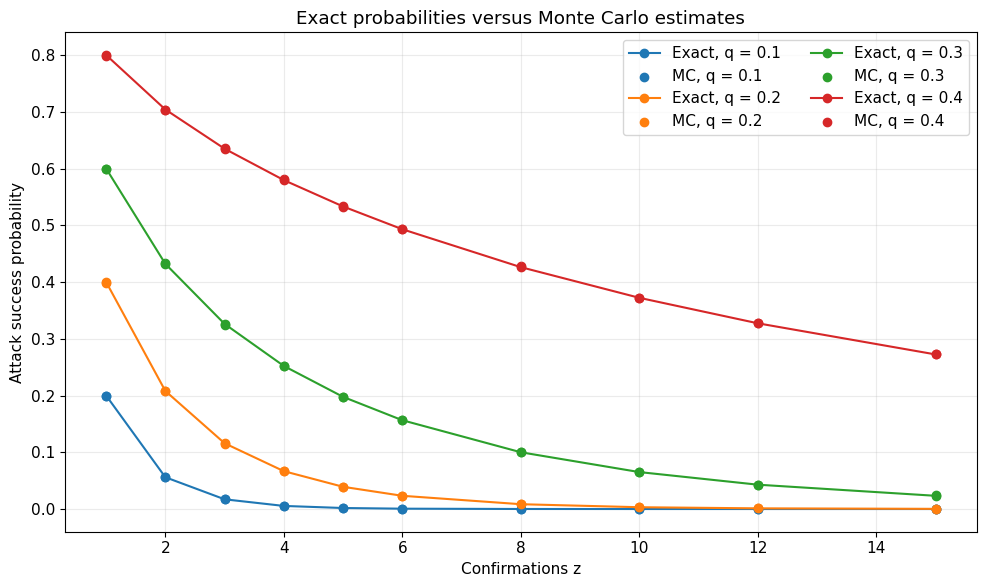

,q,z,Exact,Monte Carlo,Absolute difference
0,0.100000,1,0.200000,0.199642,-0.000358
1,0.100000,2,0.056000,0.055683,-0.000317
2,0.100000,3,0.017120,0.017817,0.000697
3,0.100000,4,0.005456,0.005375,-0.000081
4,0.100000,5,0.001782,0.001900,0.000118
5,0.100000,6,0.000591,0.000583,-0.000008
6,0.100000,8,0.000067,0.000050,-0.000017
7,0.100000,10,0.000008,0.000008,0.000000
8,0.100000,12,0.000001,0.000000,-0.000001
9,0.100000,15,0.000000,0.000000,-0.000000


In [12]:
def catch_up_probability_from_deficit(deficit, attacker_share):
    honest_share = 1.0 - attacker_share
    deficit = np.asarray(deficit, dtype=int)

    if attacker_share >= honest_share:
        return np.ones_like(deficit, dtype=float)

    ratio = attacker_share / honest_share
    return np.where(deficit <= 0, 1.0, ratio ** deficit).astype(float)


def exact_attack_success_probability(confirmations, attacker_share, tail_probability=1e-14):
    honest_share = 1.0 - attacker_share

    if attacker_share >= honest_share:
        return 1.0

    total_probability = 0.0
    k = 0
    pmf = honest_share ** confirmations

    while True:
        deficit = confirmations - k
        total_probability += pmf * float(
            catch_up_probability_from_deficit(deficit, attacker_share)
        )

        k += 1
        pmf *= (k + confirmations - 1) / k * attacker_share

        if pmf < tail_probability and k > confirmations + 20:
            break

    return total_probability


def simulate_attacker_blocks_before_confirmations(confirmations, attacker_share, n_simulations=100_000, seed=7):
    honest_share = 1.0 - attacker_share
    rng = np.random.default_rng(seed)
    return rng.negative_binomial(confirmations, honest_share, size=n_simulations)


def simulate_double_spend_success_probability(confirmations, attacker_share, n_simulations=200_000, seed=7):
    honest_share = 1.0 - attacker_share

    if attacker_share >= honest_share:
        return 1.0

    attacker_blocks = simulate_attacker_blocks_before_confirmations(
        confirmations=confirmations,
        attacker_share=attacker_share,
        n_simulations=n_simulations,
        seed=seed,
    )

    remaining_deficit = confirmations - attacker_blocks
    eventual_catch_up = catch_up_probability_from_deficit(remaining_deficit, attacker_share)

    rng = np.random.default_rng(seed + 1)
    success_draws = rng.random(n_simulations) < eventual_catch_up
    return float(success_draws.mean())


validation_shares = [0.1, 0.2, 0.3, 0.4]
validation_z = np.array([1, 2, 3, 4, 5, 6, 8, 10, 12, 15])

mc_rows = []
for q in validation_shares:
    for z in validation_z:
        exact_value = exact_attack_success_probability(z, q)
        mc_value = simulate_double_spend_success_probability(z, q, n_simulations=120_000, seed=SEED + int(100*q) + z)
        mc_rows.append(
            {
                "q": q,
                "z": z,
                "Exact": exact_value,
                "Monte Carlo": mc_value,
                "Absolute difference": mc_value - exact_value,
            }
        )
mc_table = pd.DataFrame(mc_rows)

fig, ax = plt.subplots()
for q in validation_shares:
    subset = mc_table[mc_table["q"] == q]
    ax.plot(subset["z"], subset["Exact"], marker="o", label=f"Exact, q = {q:.1f}")
    ax.scatter(subset["z"], subset["Monte Carlo"], label=f"MC, q = {q:.1f}")
ax.set_title("Exact probabilities versus Monte Carlo estimates")
ax.set_xlabel("Confirmations z")
ax.set_ylabel("Attack success probability")
ax.legend(ncol=2)
fig.tight_layout()
plt.show()

mc_table


### 5.3.1 Monte Carlo error summary

The next table compresses the Monte Carlo validation into a few simple statistics.

For each attacker share $q$, we compute the mean absolute simulation error, the largest absolute simulation error, and the mean signed difference. The signed difference is useful because it can show whether the simulation is systematically above or below the exact curve.

In [13]:
mc_summary = (
    mc_table.groupby("q")["Absolute difference"]
    .agg(
        Mean_absolute_difference=lambda s: np.mean(np.abs(s)),
        Max_absolute_difference=lambda s: np.max(np.abs(s)),
        Mean_signed_difference="mean",
    )
    .reset_index()
)
mc_summary

,q,Mean_absolute_difference,Max_absolute_difference,Mean_signed_difference
0,0.100000,0.000160,0.000697,0.000003
1,0.200000,0.000385,0.001098,-0.000268
2,0.300000,0.000579,0.002235,-0.000164
3,0.400000,0.001105,0.002527,0.000298


The Monte Carlo errors stay small across all tested cases. That is exactly what we want to see. It means the simulation and the exact formula are telling the same story, with only minor sampling noise left over.


The Monte Carlo estimates track the exact probabilities closely across all tested regimes. Small discrepancies are expected because simulation has sampling noise, but the differences remain minor relative to the scale of the probabilities themselves. This is strong evidence that both the formulas and the Python implementation are behaving as intended.



### 5.4 Confirmation requirements for target risk levels

The previous plots show continuous curves, but users often need a discrete decision rule: **How many confirmations are needed to push the risk below a chosen target?**

Define a target risk level $\varepsilon$. We want the smallest integer $z$ such that

$$
P_{\text{exact}}(z,q) \le \varepsilon.
$$

This is a simple idea, but it makes the practical dependence on $q$ explicit.


In [15]:
def confirmation_requirement_table(attacker_shares, target_risks, max_confirmations=200):
    rows = {}

    for attacker_share in attacker_shares:
        thresholds = []
        for target_risk in target_risks:
            found_value = np.nan
            for confirmations in range(1, max_confirmations + 1):
                if exact_attack_success_probability(confirmations, attacker_share) <= target_risk:
                    found_value = confirmations
                    break
            thresholds.append(found_value)
        rows[attacker_share] = thresholds

    frame = pd.DataFrame(rows, index=target_risks)
    frame.index.name = "target_risk"
    frame.columns.name = "attacker_share"
    return frame

requirement_shares = np.round(np.arange(0.05, 0.46, 0.05), 2)
risk_targets = [1e-2, 1e-3, 1e-4, 1e-6]

# A higher cap is needed because strong attackers may require hundreds of
# confirmations before the exact risk drops below very small thresholds.
requirement_table = confirmation_requirement_table(requirement_shares, risk_targets, max_confirmations=1200)
requirement_table


attacker_share,0.050000,0.100000,0.150000,0.200000,0.250000,0.300000,0.350000,0.400000,0.450000
target_risk,,,,,,,,,
0.010000,3,4,6,8,12,20,36,82,331
0.001000,4,6,9,13,20,32,58,133,539
0.000100,5,8,12,18,27,44,81,186,754
0.000001,8,12,19,28,42,69,128,294,1191


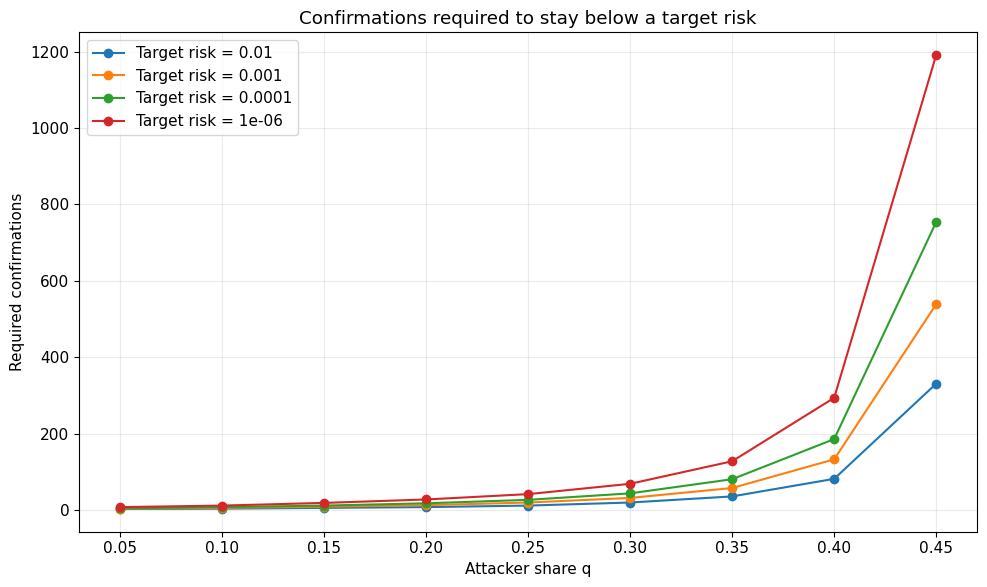

In [17]:

fig, ax = plt.subplots()
for risk in risk_targets:
    ax.plot(requirement_shares, requirement_table.loc[risk], marker="o", label=f"Target risk = {risk:g}")
ax.set_title("Confirmations required to stay below a target risk")
ax.set_xlabel("Attacker share q")
ax.set_ylabel("Required confirmations")
ax.legend()
fig.tight_layout()
plt.show()



This plot is one of the most practically informative results in the notebook.

- For small $q$, risk thresholds can be met with a manageable number of confirmations.
- As $q$ rises, the required confirmations increase nonlinearly.
- The jump becomes dramatic when the target risk is very small, such as $10^{-6}$.
- No finite confirmation count can provide asymptotic comfort once $q \ge 0.5$, because the eventual catch-up probability becomes 1.

The practical lesson is that confirmation policy is inseparable from the assumed attacker power. Security targets cannot be chosen in isolation.


## 6. Practical Interpretation

The previous section gave curves, heatmaps, and error summaries. This section turns those results into plainer decision-oriented statements.

### 6.1 What a merchant or exchange would actually care about

A business does not usually ask for a whole probability curve. It asks a simpler question:

> **If I wait for a certain number of confirmations, how much risk am I still accepting?**

The exact model lets us answer that question directly.

### 6.2 Risk snapshots for common confirmation counts

The next table reports the exact attack probability for a few commonly discussed confirmation counts.

In [5]:
import numpy as np
import pandas as pd


def catch_up_probability_from_deficit(deficit, attacker_share):
    honest_share = 1.0 - attacker_share
    deficit = np.asarray(deficit, dtype=int)

    if attacker_share >= honest_share:
        return np.ones_like(deficit, dtype=float)

    ratio = attacker_share / honest_share
    return np.where(deficit <= 0, 1.0, ratio ** deficit).astype(float)


def exact_attack_success_probability(confirmations, attacker_share, tail_probability=1e-14):
    honest_share = 1.0 - attacker_share

    if attacker_share >= honest_share:
        return 1.0

    total_probability = 0.0
    k = 0
    pmf = honest_share ** confirmations

    while True:
        deficit = confirmations - k
        total_probability += pmf * float(
            catch_up_probability_from_deficit(deficit, attacker_share)
        )

        k += 1
        pmf *= (k + confirmations - 1) / k * attacker_share

        if pmf < tail_probability and k > confirmations + 20:
            break

    return total_probability


practical_z = [1, 3, 6, 10]
practical_shares = [0.1, 0.2, 0.3, 0.4]

practical_table = pd.DataFrame(
    {
        f"q={q:.1f}": [exact_attack_success_probability(z, q) for z in practical_z]
        for q in practical_shares
    },
    index=practical_z,
)
practical_table.index.name = "Confirmations z"
practical_table

,q=0.1,q=0.2,q=0.3,q=0.4
Confirmations z,,,,
1,0.200000,0.400000,0.600000,0.800000
3,0.017120,0.115840,0.326160,0.634880
6,0.000591,0.023308,0.156450,0.493004
10,0.000008,0.003158,0.065107,0.372184


Several practical messages stand out immediately.

- With a **small attacker share** such as $q=0.1$, waiting longer reduces risk very quickly.
- With a **moderate attacker share** such as $q=0.2$, the reduction is still meaningful, but it is much slower.
- With a **strong attacker** such as $q=0.3$ or $q=0.4$, a small number of confirmations is clearly not enough.

### 6.3 Why "6 confirmations" is not a universal rule

The value $z=6$ appears often in Bitcoin discussions, but the notebook shows why it should be treated as a **heuristic** rather than a theorem.

Using the exact model:

- for $q=0.1$, the risk at $z=6$ is already very small,
- for $q=0.2$, the risk is lower but still not negligible,
- for $q=0.3$, the risk remains visibly large,
- and for $q=0.4$, six confirmations are far from enough.

So the mathematical conclusion is simple: **a confirmation policy only makes sense after we say what attacker strength we are trying to defend against and what risk level we are willing to tolerate.**

### 6.4 Confirmation targets for chosen risk levels

The requirement table from the previous section can also be read in plain language.

- If the target is only a **roughly acceptable** risk level such as $10^{-2}$, the confirmation requirement may stay moderate for weaker attackers.
- If the target is a **strict** risk level such as $10^{-6}$, the number of required confirmations can become very large.
- As $q$ approaches $0.5$, confirmation waiting becomes a weak defense because the attacker is almost as strong as the honest network.

This is the main practical value of the project: it turns a vague idea like "wait a bit longer" into a quantitative rule that depends on a clearly stated threat model.

## 7. Discussion


### 7.1 Main findings

The analysis supports several clear conclusions.

#### Finding 1: Bitcoin confirmation security is probabilistic, not absolute.
Even after several confirmations, the attacker's success probability is usually positive. Confirmations reduce risk; they do not eliminate it.

#### Finding 2: The attacker's hash-power share matters at least as much as the number of confirmations.
The same confirmation count can correspond to radically different risk levels under different values of $q$.

#### Finding 3: The right quantity is not only the current deficit, but also the attacker's hidden progress during the waiting period.
That is why the negative-binomial model is important. The merchant does not face a static deficit of exactly $z$; the attacker may already have mined part of the competing chain.

#### Finding 4: Nakamoto's Poisson approximation is useful but imperfect.
It captures the general trend and is historically elegant, but it can materially underestimate or overestimate the exact risk depending on the regime.

#### Finding 5: "Six confirmations" is a heuristic, not a theorem.
For weak attackers it may be conservative enough in practice. For stronger attackers, it may be far from sufficient if the desired risk threshold is strict.



### 7.2 Model limitations

A professional analysis should state its limits explicitly.

1. **No economics.** The model studies probability, not whether the attack is profitable.
2. **No network effects.** Real block propagation, latency, and orphaning are ignored.
3. **Constant hash-rate shares.** In reality, hash power can fluctuate over time.
4. **Infinite-horizon catch-up.** Once the merchant accepts the payment, the model gives the attacker unlimited time to continue mining. This is analytically clean but idealized.
5. **No difficulty adjustment.** Over short attack horizons this is reasonable, but it is still a simplification.
6. **No strategic behavior beyond persistent attack continuation.** Real attackers may stop early or choose targets selectively.

These limitations do not invalidate the model. They define its scope. Within that scope, the conclusions remain mathematically meaningful and operationally relevant.


## 8. Conclusion

The results support the main thesis of this project.

Bitcoin confirmations should not be interpreted as an absolute guarantee of safety. Instead, they should be understood as a probabilistic protection mechanism whose effectiveness depends strongly on the attacker's share of the total hash power.

The analysis showed three main results. First, when the attacker controls less than 50\% of the hash power, the probability of a successful double-spend attack decreases as the number of confirmations increases. Second, this decrease is not equally fast in all cases: when the attacker share $q$ is larger, the risk remains significant for a longer time. Third, the exact model and the Poisson approximation do not always produce the same values, which means that the approximation should be used with care when more precise estimates are needed.

A practical consequence of this result is that there is no single confirmation rule that is optimal in every situation. The number of confirmations that should be considered "safe enough" depends on the assumed attacker strength and on the acceptable level of risk.

Overall, the project shows how a security question from Bitcoin can be studied with tools from probability, statistics, and simulation. The final conclusion is that confirmation security in Proof of Work is fundamentally probabilistic, and that its interpretation is more accurate when expressed as a family of risk curves rather than as a universal fixed rule.

## 9. References

1. **Satoshi Nakamoto.** *Bitcoin: A Peer-to-Peer Electronic Cash System.* 2008.  
   Available at: [https://bitcoin.org/bitcoin.pdf](https://bitcoin.org/bitcoin.pdf)

2. **Meni Rosenfeld.** *Analysis of Hashrate-Based Double Spending.* arXiv:1402.2009, 2014.  
   Available at: [https://arxiv.org/abs/1402.2009](https://arxiv.org/abs/1402.2009)

3. **MIT OpenCourseWare.** *Chapter 2: Poisson Processes* from *Discrete Stochastic Processes*.  
   Used for the interpretation of block arrivals as Poisson processes and exponential waiting times.  
   Available at: [https://ocw.mit.edu/courses/6-262-discrete-stochastic-processes-spring-2011/3a19ce0e02d0008877351bfa24f3716a_MIT6_262S11_chap02.pdf](https://ocw.mit.edu/courses/6-262-discrete-stochastic-processes-spring-2011/3a19ce0e02d0008877351bfa24f3716a_MIT6_262S11_chap02.pdf)

4. **NIST/SEMATECH e-Handbook of Statistical Methods.** *Exponential Distribution.*  
   Used for the density, survival function, mean, and variance of the exponential model.  
   Available at: [https://www.itl.nist.gov/div898/handbook/apr/section1/apr161.htm](https://www.itl.nist.gov/div898/handbook/apr/section1/apr161.htm)

5. **NIST/SEMATECH e-Handbook of Statistical Methods.** *Homogeneous Poisson Process (HPP).*  
   Used for the interpretation of event counts and arrival rates in continuous time.  
   Available at: [https://www.itl.nist.gov/div898/handbook/apr/section1/apr171.htm](https://www.itl.nist.gov/div898/handbook/apr/section1/apr171.htm)

6. **University of Cambridge.** *Introduction to Probability – Lecture 4: Poisson, Geometric, Negative Binomial, Hypergeometric.*  
   Used for the negative-binomial and Poisson distribution background in the notebook.  
   Available at: [https://www.cl.cam.ac.uk/teaching/2425/IntroProb/slides/04-poisson-geometric-discr-rv-all-handout.pdf](https://www.cl.cam.ac.uk/teaching/2425/IntroProb/slides/04-poisson-geometric-discr-rv-all-handout.pdf)

7. **Stanford CS109.** *Bernoulli and Geometric, Expectation and Variance.*  
   Used for the standard Bernoulli-trial and geometric-distribution results.  
   Available at: [https://web.stanford.edu/class/archive/cs/cs109/cs109.1248/lectures/7-BernoulliBinomial/7-BernoulliBinomial.pdf](https://web.stanford.edu/class/archive/cs/cs109/cs109.1248/lectures/7-BernoulliBinomial/7-BernoulliBinomial.pdf)

8. **Mike Giles (University of Oxford).** *Monte Carlo Methods for Uncertainty Quantification.*  
   Used as background for the simulation-based validation approach in the Monte Carlo section.  
   Available at: [https://people.maths.ox.ac.uk/gilesm/infomm/lec1.pdf](https://people.maths.ox.ac.uk/gilesm/infomm/lec1.pdf)